# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.


,Suburb,Rooms,Type,Price,Distance,Landsize,BuildingArea,YearBuilt,Regionname,Bathroom,Car
0,Camberwell,2,h,978000.0,9.5,236.0,163.0,2003,Southern Metropolitan,2,0
1,Footscray,3,h,706000.0,5.8,94.0,123.0,1977,Southern Metropolitan,1,1
2,St Kilda,2,h,753000.0,2.9,21.0,100.0,1978,Southern Metropolitan,1,3
3,Camberwell,1,h,328000.0,1.9,742.0,52.0,1942,South-Eastern Metropolitan,3,2
4,Carlton,5,u,1052000.0,0.3,1589.0,167.0,1996,Southern Metropolitan,3,2


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [2]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Suburb        600 non-null    object 
 1   Rooms         600 non-null    int32  
 2   Type          600 non-null    object 
 3   Price         600 non-null    float64
 4   Distance      600 non-null    float64
 5   Landsize      600 non-null    float64
 6   BuildingArea  600 non-null    float64
 7   YearBuilt     600 non-null    int32  
 8   Regionname    600 non-null    object 
 9   Bathroom      600 non-null    int32  
 10  Car           600 non-null    int32  
dtypes: float64(4), int32(4), object(3)
memory usage: 42.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Suburb,600,7,Footscray,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,600.0,NaN,NaN,NaN,3.021667,1.447304,1.0,2.0,3.0,4.0,5.0
Type,600,3,h,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,600.0,NaN,NaN,NaN,815758.333333,345115.17508,227000.0,564000.0,746000.0,979750.0,2616000.0
Distance,600.0,NaN,NaN,NaN,7.682667,7.586311,0.0,2.5,5.3,10.8,49.0
Landsize,600.0,NaN,NaN,NaN,392.761667,369.926435,0.0,115.75,284.0,542.0,2349.0
BuildingArea,600.0,NaN,NaN,NaN,149.223333,50.03438,30.0,115.75,148.0,182.0,346.0
YearBuilt,600.0,NaN,NaN,NaN,1958.986667,33.961382,1900.0,1929.0,1957.0,1988.0,2017.0
Regionname,600,5,Northern Metropolitan,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bathroom,600.0,NaN,NaN,NaN,1.96,0.799666,1.0,1.0,2.0,3.0,3.0


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience:

The audience is a property investment fund client who is interested in making investment decisions in the Melbourne real-estate market.

2. Exploratory or explanatory:

This is exploratory analysis because I am examining the dataset to understand its structure and discover patterns before presenting the findings to the client.

3. Question the client cares about:

Which Melbourne region offers the best investment opportunity based on property prices and the relationship between land size and price?


## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:Bar chart

**Why:**A bar chart is appropriate because the goal is to compare a quantitative value, average price, across discrete categories, which are the regions.


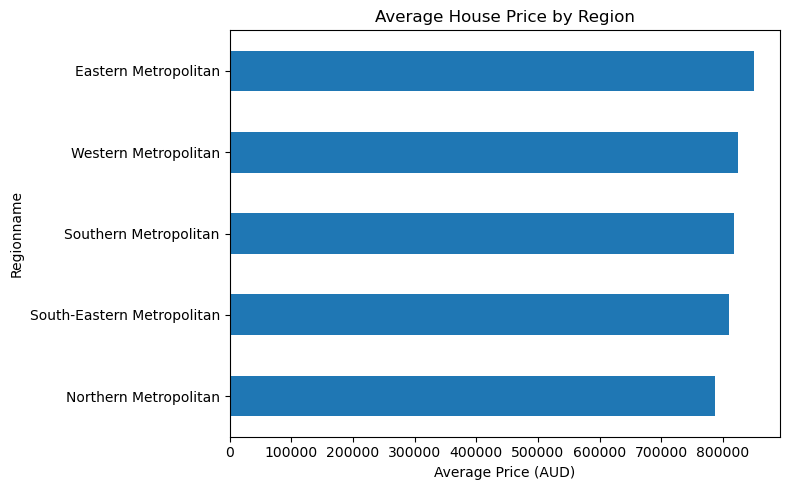

In [3]:
# Part 2.1: Average Price by Region

region_avg = (
    df.groupby("Regionname")["Price"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))

region_avg.plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")

plt.tight_layout()
plt.show()

### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:Scatter plot

**Why:**A scatter plot is appropriate because the goal is to examine the relationship between two quantitative variables, land size and price.


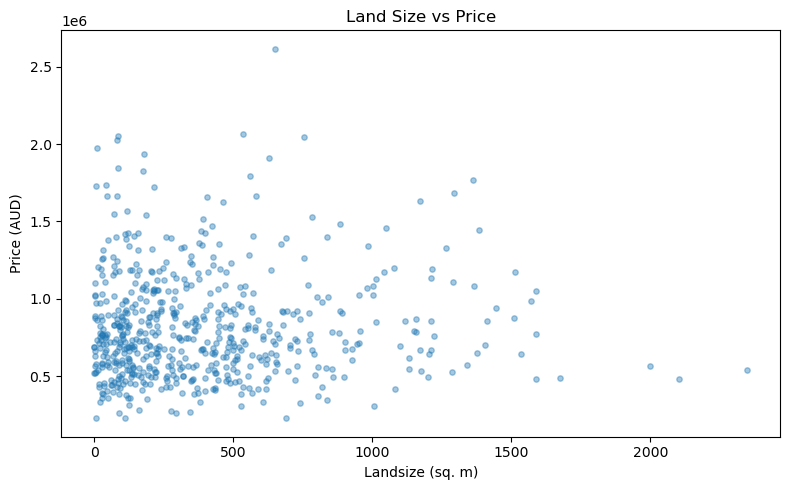

In [4]:
# Part 2.2: Land Size vs Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df["Landsize"],
    df["Price"],
    alpha=0.4,
    s=15
)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")

plt.tight_layout()
plt.show()

### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:Histogram

Why:

A histogram is appropriate because the goal is to understand the distribution and spread of property prices across the market.




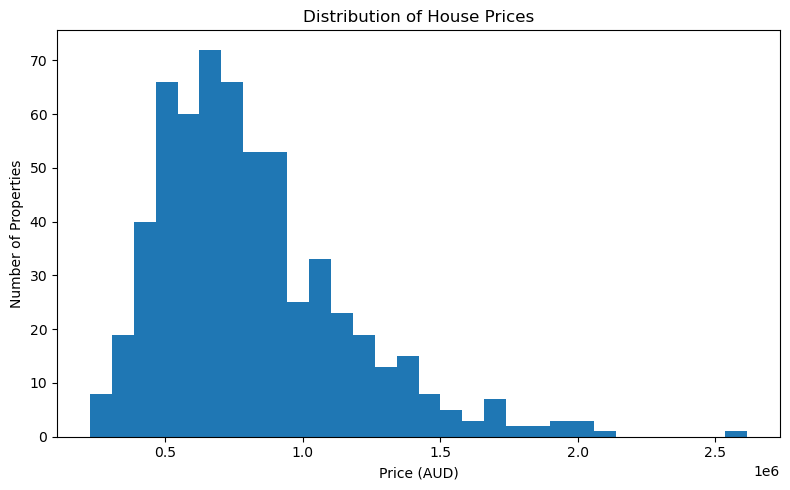

In [5]:
# Part 2.3: Distribution of Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["Price"].dropna(),
    bins=30
)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")

plt.tight_layout()
plt.show()

## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


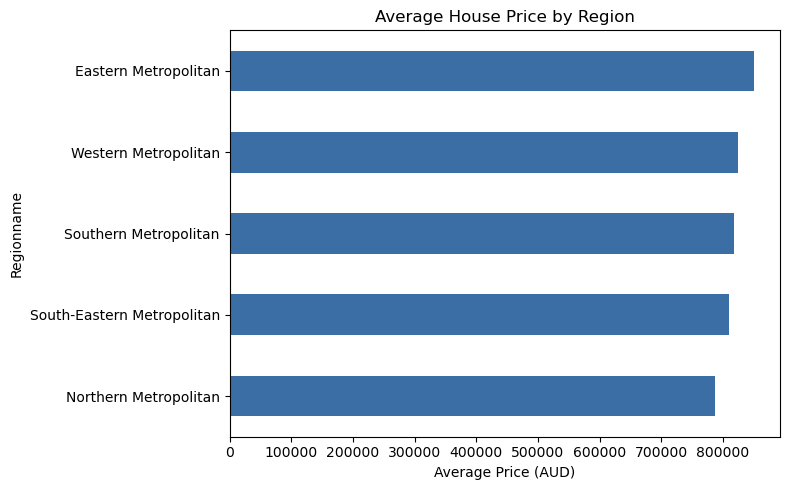

PNG size: 45.7 KB
JPEG size: 62.1 KB


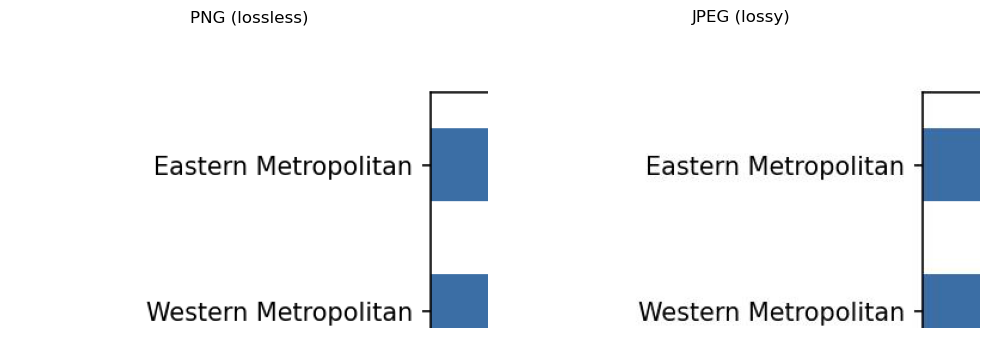

In [6]:
# Part 3: PNG vs JPEG

fig, ax = plt.subplots(figsize=(8, 5))

region_avg.plot(
    kind="barh",
    ax=ax,
    color="#3b6ea5"
)

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")

plt.tight_layout()

# Save in both formats
fig.savefig(
    "region_chart.png",
    dpi=150
)

fig.savefig(
    "region_chart.jpg",
    dpi=150
)

plt.show()


# Compare file sizes
png_size = os.path.getsize("region_chart.png")
jpg_size = os.path.getsize("region_chart.jpg")

print(f"PNG size: {png_size/1024:.1f} KB")
print(f"JPEG size: {jpg_size/1024:.1f} KB")


# Inspect compression
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, fname, label in zip(
    axes,
    ["region_chart.png", "region_chart.jpg"],
    ["PNG (lossless)", "JPEG (lossy)"]
):

    img = Image.open(fname)

    w, h = img.size

    crop = img.crop(
        (0, 0, w // 3, h // 3)
    )

    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1.

PNG was larger than JPEG. This generally matches the lecture because PNG uses lossless compression while JPEG uses lossy compression and removes some image detail to reduce file size.

2.

PNG should be used for the client briefing because it preserves sharp text, lines, labels, and chart edges without the compression artifacts that JPEG can introduce.


## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


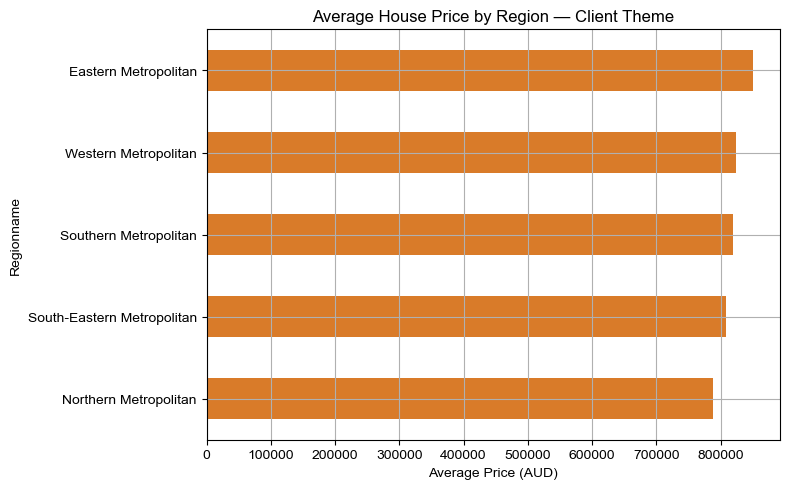

In [7]:
# Part 4: Separating Content from Design

fig, ax = plt.subplots(figsize=(8, 5))

plt.style.use(
    "seaborn-v0_8-darkgrid"
    if "seaborn-v0_8-darkgrid" in plt.style.available
    else "ggplot"
)

# Same data — only design changes
region_avg.plot(
    kind="barh",
    ax=ax,
    color="#d97b29"
)

ax.set_xlabel("Average Price (AUD)")
ax.set_title(
    "Average House Price by Region — Client Theme"
)

plt.tight_layout()
plt.show()

plt.style.use("default")

### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:**


## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task   No, changing the color, theme, or style did not change any underlying numbers in region_avg. This separation matters because designers can change the visual appearance of a chart without accidentally changing the analysis or data behind it.

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:**

Property prices vary substantially across Melbourne regions, and the relationship between land size and price can help identify where larger land holdings may offer greater investment value._________________________________________________________________

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?
A scatter plot is designed to show relationships between quantitative variables, not to compare one summary value across categories. A bar chart makes regional price differences much easier to compare.
2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?
JPEG uses lossy compression, which can create artifacts around text, lines, and sharp edges. PNG preserves these details better.
3. Name one thing that counts as "design" (not "content") in a chart.
Color.

